# Car Damage Prediction Project

#### Import Libraries and set the device

In [2]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt
import optuna

In [3]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)


mps


### Load Data

In [4]:
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
import shutil
ipynb_path = os.path.join("dataset", ".ipynb_checkpoints")
if os.path.exists(ipynb_path):
    shutil.rmtree(ipynb_path)

In [6]:
dataset_path = "dataset"
dataset = datasets.ImageFolder(dataset_path,transform=image_transforms)
len(dataset)
                              

2300

In [8]:
class_names = dataset.classes
class_names

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [7]:
num_classes = len(dataset.classes)
num_classes

6

In [8]:
train_size = int(0.75*len(dataset))
val_size  = len(dataset)-train_size
train_size,val_size

(1725, 575)

In [9]:
train_dataset, val_dataset = random_split(dataset,[train_size,val_size])

In [10]:
train_dataloader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_dataloader = DataLoader(val_dataset,batch_size=32,shuffle=True)

In [11]:
for images, labels in train_dataloader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [12]:
img = images[0]

In [13]:
img.shape

torch.Size([3, 224, 224])

In [14]:
img.permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


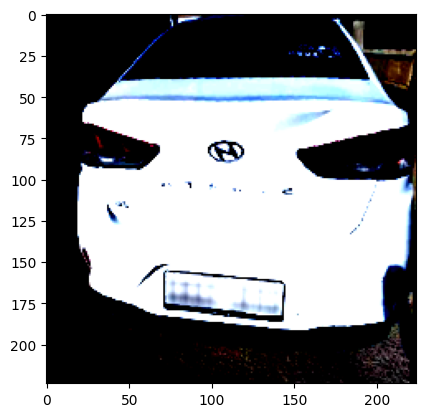

In [15]:
plt.imshow(img.permute(1,2,0))
plt.show()

### Model 1: CNN

In [16]:
class CarClassifierCNN(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,stride=1,padding=1), # (3,224,224) -> (16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0), #(16,224,224)->(16,112,112)

            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1), # (16,224,224) -> (32,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0), #(32,112,112)->(32,56,56)

            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1), # (32,56,56) -> (64,56,56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0), #(64,56,56)->(64,28,28)

            nn.Flatten(),

            nn.Linear(64*28*28,512),
            nn.ReLU(),

            nn.Linear(512,num_classes)  
        )

    def forward(self,x):
        x = self.network(x)
        return x

In [17]:
model = CarClassifierCNN(num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [18]:
def train_model(model, criterion, optimizer, train_loader, val_loader, device, epochs=10):
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_preds, best_labels = [], []

    for epoch in range(epochs):
        # --- Training phase ---
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        history["train_loss"].append(train_loss)

        # --- Validation phase ---
        model.eval()
        correct, total = 0, 0
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = 100 * correct / total

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Track best predictions
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_preds = all_preds
            best_labels = all_labels

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} "
              f"Val Loss: {val_loss:.4f} "
              f"Val Acc: {val_acc:.2f}%")

    return best_labels, best_preds, history


In [19]:
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

all_labels, all_predictions,_ = train_model(model, criterion, optimizer, train_loader=train_dataloader,
    val_loader=val_dataloader,
    device=device,epochs=10)

Epoch [1/10] Train Loss: 1.7424 Val Loss: 1.4445 Val Acc: 42.43%
Epoch [2/10] Train Loss: 1.4195 Val Loss: 1.2192 Val Acc: 51.48%
Epoch [3/10] Train Loss: 1.2617 Val Loss: 1.1868 Val Acc: 51.83%
Epoch [4/10] Train Loss: 1.1470 Val Loss: 1.1186 Val Acc: 52.35%
Epoch [5/10] Train Loss: 1.0822 Val Loss: 1.0577 Val Acc: 57.22%
Epoch [6/10] Train Loss: 1.0157 Val Loss: 1.0150 Val Acc: 54.26%
Epoch [7/10] Train Loss: 0.8986 Val Loss: 0.9764 Val Acc: 57.74%
Epoch [8/10] Train Loss: 0.8288 Val Loss: 0.9799 Val Acc: 58.26%
Epoch [9/10] Train Loss: 0.7825 Val Loss: 1.0068 Val Acc: 57.22%
Epoch [10/10] Train Loss: 0.7136 Val Loss: 1.0061 Val Acc: 58.61%


### Model 2: CNN with Regularization

In [20]:
class CarClassifierCNNWithRegularization(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), # (16, 224, 224) 
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (16, 112, 112)
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (32, 56, 56)    
            
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (64, 28, 28)
            
            nn.Flatten(),
            
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.network(x)
        return x

In [21]:
model = CarClassifierCNNWithRegularization(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

all_labels, all_predictions,_ = train_model(model, criterion, optimizer,  epochs=10, train_loader=train_dataloader,
    val_loader=val_dataloader,
    device=device)

Epoch [1/10] Train Loss: 6.8021 Val Loss: 1.2774 Val Acc: 47.65%
Epoch [2/10] Train Loss: 1.3617 Val Loss: 1.1388 Val Acc: 51.48%
Epoch [3/10] Train Loss: 1.2465 Val Loss: 1.1009 Val Acc: 51.13%
Epoch [4/10] Train Loss: 1.1892 Val Loss: 1.0211 Val Acc: 55.30%
Epoch [5/10] Train Loss: 1.1383 Val Loss: 1.0220 Val Acc: 50.26%
Epoch [6/10] Train Loss: 1.1304 Val Loss: 1.0547 Val Acc: 53.74%
Epoch [7/10] Train Loss: 1.1058 Val Loss: 1.0039 Val Acc: 56.70%
Epoch [8/10] Train Loss: 1.0847 Val Loss: 1.0166 Val Acc: 52.70%
Epoch [9/10] Train Loss: 1.0667 Val Loss: 1.0445 Val Acc: 52.52%
Epoch [10/10] Train Loss: 1.0727 Val Loss: 0.9886 Val Acc: 54.09%


### Model 3: Transfer Learning with EfficientNet

In [22]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')
        
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
        
        in_features = self.model.classifier[1].in_features
        
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )
        
    def forward(self, x):
        x = self.model(x)
        return x           

In [23]:
model = CarClassifierEfficientNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001) #optimise only the parameters that needs gradient computation

all_labels, all_predictions,_ = train_model(model, criterion, optimizer, train_loader=train_dataloader,
    val_loader=val_dataloader,
    device=device, epochs=10)

Epoch [1/10] Train Loss: 1.5005 Val Loss: 1.2086 Val Acc: 57.74%
Epoch [2/10] Train Loss: 1.1246 Val Loss: 1.0200 Val Acc: 62.26%
Epoch [3/10] Train Loss: 1.0150 Val Loss: 0.9406 Val Acc: 64.87%
Epoch [4/10] Train Loss: 0.9477 Val Loss: 0.9133 Val Acc: 65.74%
Epoch [5/10] Train Loss: 0.8996 Val Loss: 0.8694 Val Acc: 66.78%
Epoch [6/10] Train Loss: 0.8647 Val Loss: 0.8675 Val Acc: 66.43%
Epoch [7/10] Train Loss: 0.8480 Val Loss: 0.8330 Val Acc: 65.39%
Epoch [8/10] Train Loss: 0.8183 Val Loss: 0.8296 Val Acc: 67.13%
Epoch [9/10] Train Loss: 0.8042 Val Loss: 0.8266 Val Acc: 66.78%
Epoch [10/10] Train Loss: 0.8030 Val Loss: 0.8419 Val Acc: 65.39%


### Model 4: Transfer Learning with ResNet

In [24]:
# Load the pre-trained ResNet model
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True            
            
        # Replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [25]:
model = CarClassifierResNet(num_classes=num_classes, dropout_rate=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

labels, predictions, history = train_model(
    model, criterion, optimizer,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    device=device,
    epochs=10
)

Epoch [1/10] Train Loss: 0.8664 Val Loss: 0.6385 Val Acc: 76.17%
Epoch [2/10] Train Loss: 0.4957 Val Loss: 0.5781 Val Acc: 79.65%
Epoch [3/10] Train Loss: 0.3541 Val Loss: 0.5993 Val Acc: 77.91%
Epoch [4/10] Train Loss: 0.2354 Val Loss: 0.5558 Val Acc: 78.78%
Epoch [5/10] Train Loss: 0.2217 Val Loss: 0.5541 Val Acc: 79.48%
Epoch [6/10] Train Loss: 0.1607 Val Loss: 0.6463 Val Acc: 80.00%
Epoch [7/10] Train Loss: 0.1648 Val Loss: 0.8115 Val Acc: 78.61%
Epoch [8/10] Train Loss: 0.1199 Val Loss: 0.6564 Val Acc: 82.09%
Epoch [9/10] Train Loss: 0.1080 Val Loss: 0.5603 Val Acc: 80.35%
Epoch [10/10] Train Loss: 0.0934 Val Loss: 0.6764 Val Acc: 80.70%


In [26]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(labels, predictions)
print(f"Best Validation Accuracy: {acc*100:.2f}%")

Best Validation Accuracy: 82.09%


### Hyperparameter Tuning

In [27]:
import numpy as np
import random

In [28]:
def objective(trial):
    # ---- Reproducibility ----
    seed = 42
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # ---- Hyperparameters ----
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.3, 0.6)

    # ---- Model ----
    model = CarClassifierResNet(num_classes=num_classes, dropout_rate=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    # ---- Scheduler ----
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.7)

    # ---- Training settings ----
    epochs = 3
    acc_history = []
    best_acc = 0
    patience = 2  # Early stopping patience
    no_improve_count = 0

    print(f"\nStarting Trial {trial.number+1} | lr={lr:.6f}, dropout={dropout_rate:.2f}")

    for epoch in range(epochs):
        print(f"Epoch {epoch+1} started..")
        model.train()
        running_loss = 0.0

        for batch_idx, (images, labels) in enumerate(train_dataloader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # ---- Batch-level pruning ----
            if batch_idx % 5 == 0:  # Every 5 batches
                interim_acc = (100 * torch.sum(torch.argmax(outputs, 1) == labels).item()) / labels.size(0)
                trial.report(interim_acc, step=epoch * len(train_dataloader) + batch_idx)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()

        # ---- Validation ----
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_dataloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        acc_history.append(accuracy)
        print(f"    Epoch [{epoch+1}/{epochs}] - Val Acc: {accuracy:.2f}%")

        # ---- Early stopping ----
        if accuracy > best_acc:
            best_acc = accuracy
            no_improve_count = 0
        else:
            no_improve_count += 1
            if no_improve_count >= patience:
                print("Early stopping triggered.")
                break

        # ---- Scheduler step ----
        scheduler.step()

    # ✅ Return the best accuracy in this trial, not the mean
    return max(acc_history)

In [29]:
pruner = optuna.pruners.MedianPruner(
    n_startup_trials=1,   # Only let the first trial run fully
    n_warmup_steps=0,     # Prune from the first reported value
    interval_steps=5      # Check pruning every 5 reports to reduce overhead
)
study = optuna.create_study(direction="maximize", pruner=pruner)
study.optimize(objective, n_trials=10)


[I 2025-08-10 18:31:56,683] A new study created in memory with name: no-name-eb576a65-3289-4974-a11d-5e4aac36cfe7



Starting Trial 1 | lr=0.004660, dropout=0.50
Epoch 1 started..
    Epoch [1/3] - Val Acc: 63.83%
Epoch 2 started..
    Epoch [2/3] - Val Acc: 80.70%
Epoch 3 started..


[I 2025-08-10 18:36:45,154] Trial 0 finished with value: 80.69565217391305 and parameters: {'lr': 0.004660458242834929, 'dropout_rate': 0.4979481712061412}. Best is trial 0 with value: 80.69565217391305.


    Epoch [3/3] - Val Acc: 80.17%

Starting Trial 2 | lr=0.001414, dropout=0.30
Epoch 1 started..
    Epoch [1/3] - Val Acc: 70.09%
Epoch 2 started..


[I 2025-08-10 18:39:14,637] Trial 1 pruned. 


...

[I 2025-08-10 18:40:07,905] Trial 7 pruned. 



Starting Trial 9 | lr=0.003692, dropout=0.32
Epoch 1 started..


[I 2025-08-10 18:40:51,736] Trial 8 pruned. 



Starting Trial 10 | lr=0.000287, dropout=0.47
Epoch 1 started..


[I 2025-08-10 18:41:01,130] Trial 9 pruned. 


In [30]:
study.best_params

{'lr': 0.004660458242834929, 'dropout_rate': 0.4979481712061412}

In [31]:
study.best_trial

FrozenTrial(number=0, state=1, values=[80.69565217391305], datetime_start=datetime.datetime(2025, 8, 10, 18, 31, 56, 684126), datetime_complete=datetime.datetime(2025, 8, 10, 18, 36, 45, 153299), params={'lr': 0.004660458242834929, 'dropout_rate': 0.4979481712061412}, user_attrs={}, system_attrs={}, intermediate_values={0: 6.25, 5: 71.875, 10: 56.25, 15: 46.875, 20: 65.625, 25: 71.875, 30: 78.125, 35: 75.0, 40: 65.625, 45: 56.25, 50: 78.125, 54: 56.25, 59: 71.875, 64: 81.25, 69: 78.125, 74: 78.125, 79: 81.25, 84: 75.0, 89: 87.5, 94: 93.75, 99: 71.875, 104: 87.5, 108: 75.0, 113: 81.25, 118: 81.25, 123: 84.375, 128: 84.375, 133: 87.5, 138: 84.375, 143: 84.375, 148: 90.625, 153: 93.75, 158: 81.25}, distributions={'lr': FloatDistribution(high=0.01, log=True, low=0.0001, step=None), 'dropout_rate': FloatDistribution(high=0.6, log=False, low=0.3, step=None)}, trial_id=0, value=None)

In [32]:
study.best_value

80.69565217391305

In [33]:
lr = round(study.best_params['lr'],3)

In [34]:
lr

0.005

In [35]:
dropout_rate = round(study.best_params['dropout_rate'],2)

In [36]:
dropout_rate

0.5

In [37]:
model = CarClassifierResNet(num_classes=num_classes, dropout_rate=dropout_rate).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

labels, predictions, history = train_model(
    model, criterion, optimizer,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    device=device,
    epochs=10
)


Epoch [1/10] Train Loss: 0.8877 Val Loss: 1.0448 Val Acc: 66.96%
Epoch [2/10] Train Loss: 0.5467 Val Loss: 0.6435 Val Acc: 73.04%
Epoch [3/10] Train Loss: 0.4349 Val Loss: 0.6238 Val Acc: 77.04%
Epoch [4/10] Train Loss: 0.3627 Val Loss: 0.8048 Val Acc: 75.30%
Epoch [5/10] Train Loss: 0.3275 Val Loss: 0.7468 Val Acc: 77.04%
Epoch [6/10] Train Loss: 0.2493 Val Loss: 0.5858 Val Acc: 80.35%
Epoch [7/10] Train Loss: 0.1773 Val Loss: 0.8209 Val Acc: 75.65%
Epoch [8/10] Train Loss: 0.1768 Val Loss: 0.6542 Val Acc: 80.35%
Epoch [9/10] Train Loss: 0.1203 Val Loss: 0.5382 Val Acc: 82.78%
Epoch [10/10] Train Loss: 0.1447 Val Loss: 0.9211 Val Acc: 79.83%


In [38]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(labels, predictions)
print(f"Best Validation Accuracy: {acc*100:.2f}%")

Best Validation Accuracy: 82.78%


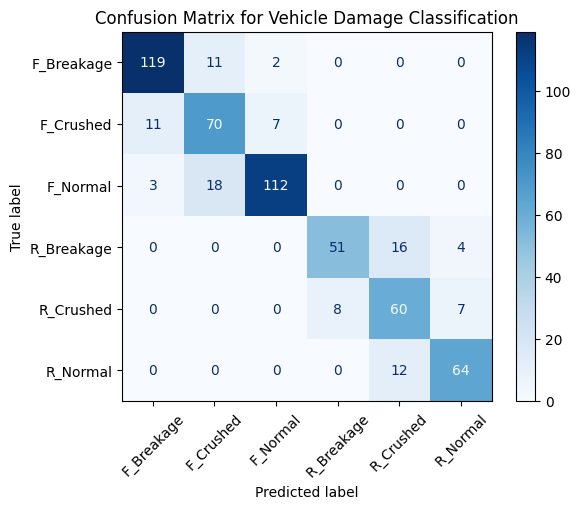

In [39]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

### Save the model

In [40]:
torch.save(model.state_dict(), 'saved_model_final.pth')